<a href="https://colab.research.google.com/github/shreyoshi2304/RNN-Auditory/blob/main/auditory_trial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0, Loss 24.8493
Epoch 30, Loss 4.3565
Epoch 60, Loss 4.2055
Epoch 90, Loss 4.1829
Epoch 120, Loss 4.1201


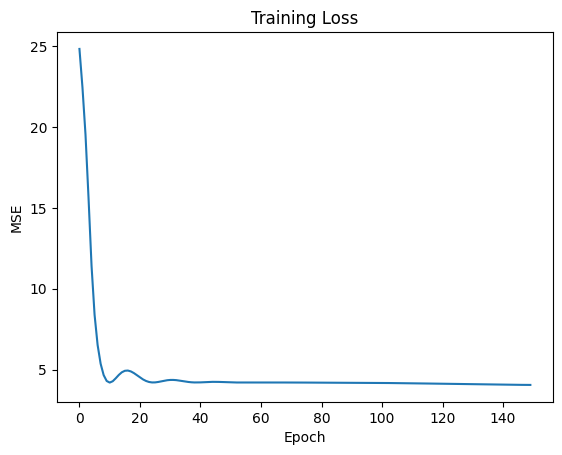

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# 1. DATA GENERATION

def generate_data(n_samples=300, seq_len=100):
    X = []
    Y = []

    for _ in range(n_samples):
        freq = np.random.uniform(1, 8)  # Hz
        t = np.linspace(0, 1, seq_len)

        signal = np.sin(2 * np.pi * freq * t)

        # add noise
        signal += np.random.normal(0, 0.2, size=seq_len)

        X.append(signal)
        Y.append(freq)

    X = np.array(X)
    Y = np.array(Y)

    return X, Y


X, Y = generate_data()

# Convert to torch
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
Y = torch.tensor(Y, dtype=torch.float32)

# 2. MODEL

class AuditoryRNN(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.rnn(x)
        return self.fc(out[:, -1, :]), out


model = AuditoryRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 3. TRAINING

losses = []

for epoch in range(150):
    optimizer.zero_grad()

    pred, _ = model(X)
    loss = criterion(pred.squeeze(), Y)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 30 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.4f}")

# 4. LOSS CURVE

plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

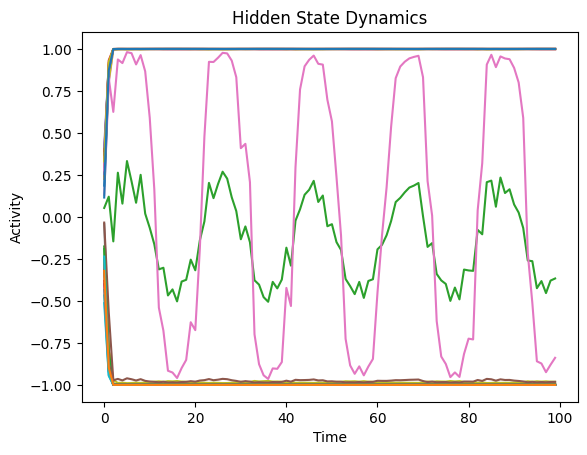

In [ ]:
sample = X[0:1]

with torch.no_grad():
    pred, hidden_seq = model(sample)

hidden_seq = hidden_seq.squeeze().numpy()

plt.figure()
plt.plot(hidden_seq)
plt.title("Hidden State Dynamics")
plt.xlabel("Time")
plt.ylabel("Activity")
plt.show()

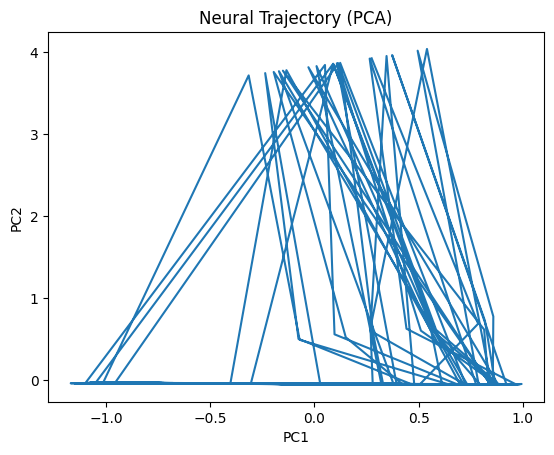

In [ ]:
from sklearn.decomposition import PCA

# collect hidden states from multiple samples
all_hidden = []

with torch.no_grad():
    for i in range(20):
        _, h = model(X[i:i+1])
        all_hidden.append(h.squeeze().numpy())

all_hidden = np.concatenate(all_hidden, axis=0)

# PCA
pca = PCA(n_components=2)
proj = pca.fit_transform(all_hidden)

plt.figure()
plt.plot(proj[:,0], proj[:,1])
plt.title("Neural Trajectory (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

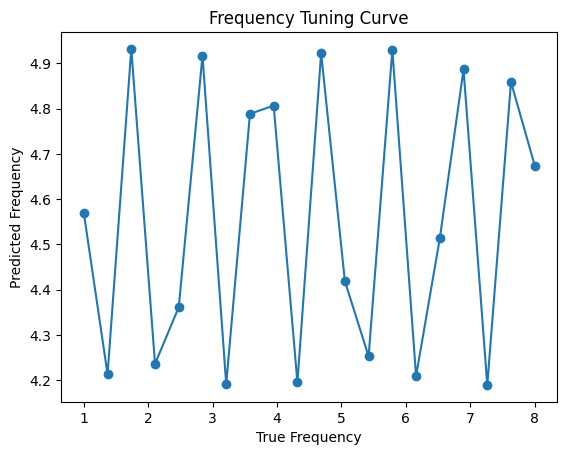

In [ ]:
test_freqs = np.linspace(1, 8, 20)
responses = []

for f in test_freqs:
    t = np.linspace(0, 1, 100)
    signal = np.sin(2 * np.pi * f * t)
    signal = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

    with torch.no_grad():
        pred, _ = model(signal)

    responses.append(pred.item())

plt.figure()
plt.plot(test_freqs, responses, 'o-')
plt.xlabel("True Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Frequency Tuning Curve")
plt.show()